# 📖 Next Word Predictor using LSTM & GRU

This project trains recurrent neural networks to predict the next word in a sequence of text, using the **full text of three Arthur Conan Doyle novels** (public domain, via Project Gutenberg):

- *The Adventures of Sherlock Holmes*
- *The Memoirs of Sherlock Holmes*
- *The Hound of the Baskervilles*

**What this notebook covers:**
1. Download & clean the combined dataset
2. Tokenize the text and build the vocabulary
3. Generate n-gram training sequences
4. Pad sequences and prepare labels (memory-efficient sparse labels)
5. Build **both an LSTM and a GRU** model and train each with **early stopping**, so training runs exactly as long as it's helping and stops automatically
6. Compare LSTM vs. GRU training curves
7. Generate text using both **greedy decoding** and **temperature-based sampling**

> Run this notebook top-to-bottom in **Google Colab**. Go to `Runtime > Change runtime type > GPU` first — with the full multi-book dataset, training is noticeably heavier than a single short document, and a GPU will save a lot of time.

## 1. Setup

Import the libraries we'll need for text processing, sequence handling, building the models, and training callbacks.

In [1]:
import re
import urllib.request
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, GRU, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.20.0


## 2. Download the Dataset

Instead of a single short document, we combine **three full Sherlock Holmes novels** from Project Gutenberg. More text means a richer vocabulary, more varied sentence structures, and ultimately a model that generates more natural predictions.

In [2]:
books = {
    "The Adventures of Sherlock Holmes": "https://www.gutenberg.org/cache/epub/1661/pg1661.txt",
    "The Memoirs of Sherlock Holmes":    "https://www.gutenberg.org/cache/epub/834/pg834.txt",
    "The Hound of the Baskervilles":     "https://www.gutenberg.org/cache/epub/2852/pg2852.txt",
}

raw_texts = {}
for title, url in books.items():
    raw_texts[title] = urllib.request.urlopen(url).read().decode("utf-8")
    print(f"{title}: {len(raw_texts[title]):,} characters downloaded")

The Adventures of Sherlock Holmes: 593,911 characters downloaded
The Memoirs of Sherlock Holmes: 600,658 characters downloaded
The Hound of the Baskervilles: 381,207 characters downloaded


## 3. Clean the Text

Every Project Gutenberg file includes license/header/footer boilerplate we don't want the model learning from, so we strip that out for **each book individually** (the boilerplate markers differ slightly per book), then apply the same light cleaning as before:
- Remove the Gutenberg header and footer
- Collapse whitespace and drop characters that aren't useful for a word-level model
- Lowercase everything (keeps the vocabulary smaller and more learnable)

Finally, we join all three cleaned books into a single training corpus.

In [3]:
def strip_gutenberg_boilerplate(text):
    start_match = re.search(r"\*\*\* START OF (THE|THIS) PROJECT GUTENBERG EBOOK.*?\*\*\*", text, re.DOTALL)
    end_match = re.search(r"\*\*\* END OF (THE|THIS) PROJECT GUTENBERG EBOOK.*?\*\*\*", text, re.DOTALL)
    if start_match:
        text = text[start_match.end():]
    if end_match:
        text = text[:end_match.start()]
    return text

def clean_text(text):
    text = text.lower()
    text = re.sub(r"[_*]", "", text)                    # remove markdown-ish emphasis chars
    text = re.sub(r"[^a-z0-9.,!?;:'\n ]", " ", text)      # keep basic punctuation only
    text = re.sub(r"[ \t]+", " ", text)                  # collapse repeated spaces
    text = re.sub(r"\n{2,}", "\n", text)                 # collapse repeated blank lines
    return text.strip()

cleaned_books = []
for title, raw in raw_texts.items():
    cleaned = clean_text(strip_gutenberg_boilerplate(raw))
    cleaned_books.append(cleaned)
    print(f"{title}: {len(cleaned):,} characters after cleaning")

corpus_text = "\n".join(cleaned_books)
print("\nTotal combined corpus length:", len(corpus_text), "characters")

The Adventures of Sherlock Holmes: 570,750 characters after cleaning
The Memoirs of Sherlock Holmes: 530,848 characters after cleaning
The Hound of the Baskervilles: 329,509 characters after cleaning

Total combined corpus length: 1431109 characters


Unlike the earlier version of this notebook, we do **not** artificially cap the number of lines here — we use the full combined text of all three books. Lines that are too short to provide useful context (fewer than 4 words) are dropped.

In [4]:
lines = [line.strip() for line in corpus_text.split("\n") if len(line.strip().split()) > 3]
corpus_text = "\n".join(lines)

print("Number of lines used:", len(lines))
print("Total words (approx):", len(corpus_text.split()))

Number of lines used: 22537
Total words (approx): 260090


## 4. Tokenization

We use Keras's `Tokenizer` to build a word-level vocabulary, mapping every unique word across all three books to an integer.

In [5]:
tokenizer = Tokenizer()
tokenizer.fit_on_texts([corpus_text])

vocab_size = len(tokenizer.word_index) + 1   # +1 for padding token (index 0)
print("Vocabulary size:", vocab_size)

Vocabulary size: 12085


## 5. Generate N-gram Training Sequences

For every line, we create progressively longer sub-sequences, so the model learns to predict a word from every possible amount of preceding context.

> ⏳ With three full books instead of a handful of FAQ lines, this will generate a **much** larger number of training sequences than before — expect this cell, and training later on, to take noticeably longer.

In [6]:
input_sequences = []

for sentence in corpus_text.split("\n"):
    tokenized_sentence = tokenizer.texts_to_sequences([sentence])[0]
    for i in range(1, len(tokenized_sentence)):
        input_sequences.append(tokenized_sentence[:i + 1])

print("Total training sequences:", len(input_sequences))
print("Example sequence:", input_sequences[10])

Total training sequences: 237573
Example sequence: [3, 6, 1296, 8, 2062]


## 6. Pad Sequences

Sequences have different lengths, but neural networks need fixed-size input. We left-pad (`padding='pre'`) every sequence up to the length of the longest one, so the word to predict always sits at the very end.

In [7]:
max_len = max(len(seq) for seq in input_sequences)
print("Max sequence length:", max_len)

padded_input_sequences = pad_sequences(input_sequences, maxlen=max_len, padding='pre')
print("Padded shape:", padded_input_sequences.shape)

Max sequence length: 19
Padded shape: (237573, 19)


## 7. Create Predictors (X) and Labels (y)

The last column of every padded sequence is the word to predict (`y`); everything before it is the input context (`X`).

**Note on labels:** the original small-vocabulary version of this project one-hot encoded `y` with `to_categorical`. With a vocabulary this much larger (and far more training sequences), one-hot encoding every label would use a huge amount of memory. Instead, we keep `y` as plain integer class labels and use `sparse_categorical_crossentropy` as the loss function later — mathematically equivalent, but far more memory-efficient.

In [8]:
X = padded_input_sequences[:, :-1]
y = padded_input_sequences[:, -1]   # integer labels, NOT one-hot encoded

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (237573, 18)
y shape: (237573,)


## 8. Training Callbacks: Early Stopping

Rather than guessing a fixed number of epochs, we let training run as long as it keeps improving and stop automatically once it doesn't:

- **`EarlyStopping`** watches validation loss (`val_loss`) and stops training if it hasn't improved for `patience` epochs in a row. `restore_best_weights=True` ensures the model ends up with the weights from its *best* epoch, not just its last one.
- **`ModelCheckpoint`** separately saves the best-performing version of the model to disk as training progresses, as a safety net.

We hold out 10% of the data (`validation_split=0.1`) purely to measure this — the model never trains on it.

In [9]:
def make_callbacks(checkpoint_path):
    return [
        EarlyStopping(
            monitor="val_loss",
            patience=6,
            restore_best_weights=True,
            verbose=1,
        ),
        ModelCheckpoint(
            checkpoint_path,
            monitor="val_loss",
            save_best_only=True,
            verbose=0,
        ),
    ]

## 9. Build the LSTM Model

An `Embedding` layer followed by two stacked `LSTM` layers and a `Dense` softmax output over the vocabulary, with light `Dropout` for regularization.

In [10]:
lstm_model = Sequential(name="lstm_model")
lstm_model.add(Embedding(vocab_size, 100, input_length=max_len - 1))
lstm_model.add(LSTM(150, return_sequences=True))
lstm_model.add(Dropout(0.2))
lstm_model.add(LSTM(150))
lstm_model.add(Dropout(0.2))
lstm_model.add(Dense(vocab_size, activation='softmax'))

lstm_model.compile(loss='sparse_categorical_crossentropy', optimizer='adam', metrics=['accuracy'])
lstm_model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "lstm_model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

## 10. Build the GRU Model

For comparison, we build a **second model with an identical shape**, but swap the `LSTM` layers for `GRU` layers. GRUs have fewer gates/parameters than LSTMs, so they're often faster to train while achieving similar performance — this notebook lets you check that empirically on this exact dataset.

In [11]:
gru_model = Sequential(name="gru_model")
gru_model.add(Embedding(vocab_size, 100, input_length=max_len - 1))
gru_model.add(GRU(150, return_sequences=True))
gru_model.add(Dropout(0.2))
gru_model.add(GRU(150))
gru_model.add(Dropout(0.2))
gru_model.add(Dense(vocab_size, activation='softmax'))

gru_model.compile(loss='sparse_categorical_crossentropy', optimizer='adam', metrics=['accuracy'])
gru_model.summary()

Model: "gru_model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru (GRU)                       │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru_1 (GRU)                     │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

## 11. Train the LSTM Model

We set a generous upper bound on epochs (`epochs=100`) — early stopping will halt training well before that if `val_loss` stops improving, so this is a ceiling, not a target.

In [12]:
lstm_history = lstm_model.fit(
    X, y,
    validation_split=0.1,
    epochs=100,
    batch_size=128,
    callbacks=make_callbacks("best_lstm_model.keras"),
    verbose=1,
)

Epoch 1/100
1671/1671 ━━━━━━━━━━━━━━━━━━━━ 30s 14ms/step - accuracy: 0.0642 - loss: 6.3356 - val_accuracy: 0.0901 - val_loss: 6.0127
Epoch 2/100
1671/1671 ━━━━━━━━━━━━━━━━━━━━ 23s 14ms/step - accuracy: 0.0999 - loss: 5.7862 - val_accuracy: 0.1134 - val_loss: 5.7770
Epoch 3/100
1671/1671 ━━━━━━━━━━━━━━━━━━━━ 22s 13ms/step - accuracy: 0.1187 - loss: 5.5346 - val_accuracy: 0.1231 - val_loss: 5.6799
Epoch 4/100
1671/1671 ━━━━━━━━━━━━━━━━━━━━ 41s 13ms/step - accuracy: 0.1308 - loss: 5.3562 - val_accuracy: 0.1314 - val_loss: 5.6197
Epoch 5/100
1671/1671 ━━━━━━━━━━━━━━━━━━━━ 22s 13ms/step - accuracy: 0.1387 - loss: 5.2066 - val_accuracy: 0.1367 - val_loss: 5.6155
Epoch 6/100
1671/1671 ━━━━━━━━━━━━━━━━━━━━ 22s 13ms/step - accuracy: 0.1448 - loss: 5.0850 - val_accuracy: 0.1403 - val_loss: 5.6251
Epoch 7/100
1671/1671 ━━━━━━━━━━━━━━━━━━━━ 22s 13ms/step - accuracy: 0.1493 - loss: 4.9845 - val_accuracy: 0.1416 - val_loss: 5.6515
Epoch 8/100
1671/1671 ━━━━━━━━━━━━━━━━━━━━ 41s 13ms/step - accuracy: 

## 12. Train the GRU Model

Same setup as the LSTM model above, so the comparison is fair — same data, same validation split, same callback configuration.

In [13]:
gru_history = gru_model.fit(
    X, y,
    validation_split=0.1,
    epochs=100,
    batch_size=128,
    callbacks=make_callbacks("best_gru_model.keras"),
    verbose=1,
)

Epoch 1/100
1671/1671 ━━━━━━━━━━━━━━━━━━━━ 24s 13ms/step - accuracy: 0.0776 - loss: 6.2257 - val_accuracy: 0.1170 - val_loss: 5.7645
Epoch 2/100
1671/1671 ━━━━━━━━━━━━━━━━━━━━ 21s 13ms/step - accuracy: 0.1242 - loss: 5.5198 - val_accuracy: 0.1336 - val_loss: 5.5174
Epoch 3/100
1671/1671 ━━━━━━━━━━━━━━━━━━━━ 21s 13ms/step - accuracy: 0.1423 - loss: 5.2295 - val_accuracy: 0.1449 - val_loss: 5.4485
Epoch 4/100
1671/1671 ━━━━━━━━━━━━━━━━━━━━ 22s 13ms/step - accuracy: 0.1529 - loss: 5.0239 - val_accuracy: 0.1487 - val_loss: 5.4359
Epoch 5/100
1671/1671 ━━━━━━━━━━━━━━━━━━━━ 22s 13ms/step - accuracy: 0.1607 - loss: 4.8545 - val_accuracy: 0.1516 - val_loss: 5.4357
Epoch 6/100
1671/1671 ━━━━━━━━━━━━━━━━━━━━ 21s 12ms/step - accuracy: 0.1683 - loss: 4.7006 - val_accuracy: 0.1550 - val_loss: 5.4660
Epoch 7/100
1671/1671 ━━━━━━━━━━━━━━━━━━━━ 22s 13ms/step - accuracy: 0.1769 - loss: 4.5652 - val_accuracy: 0.1568 - val_loss: 5.4964
Epoch 8/100
1671/1671 ━━━━━━━━━━━━━━━━━━━━ 22s 13ms/step - accuracy: 

## 13. Compare LSTM vs. GRU

Plotting both models' training and validation curves on the same axes makes it easy to see which converged faster, which generalized better (lower `val_loss`), and whether either one overfit (training metrics much better than validation metrics).

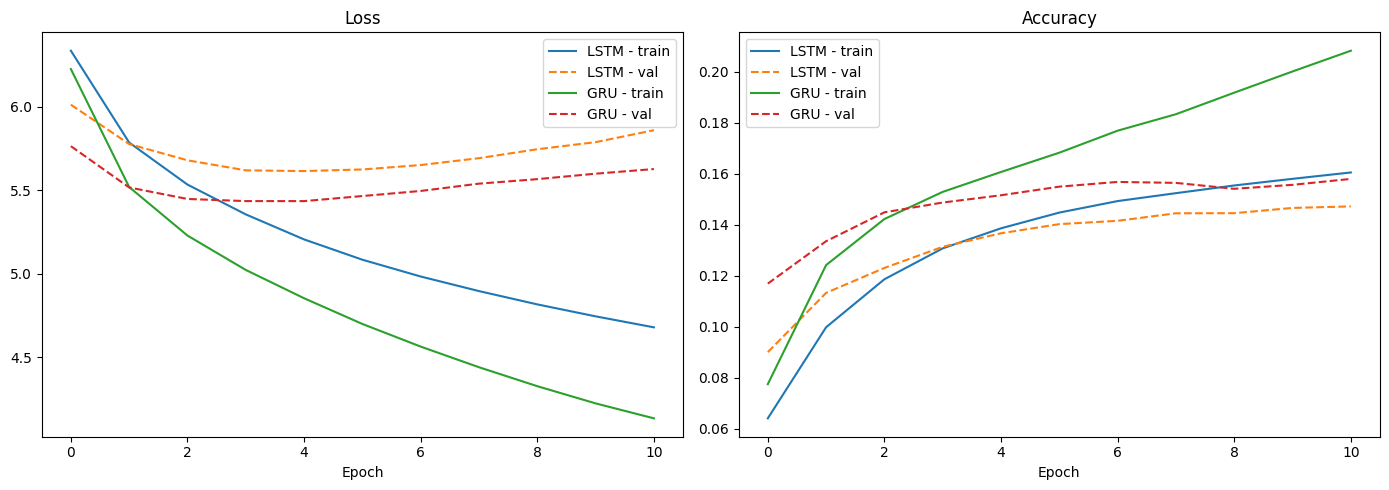

LSTM best val_loss: 5.6155 (val_accuracy: 0.1472)
GRU  best val_loss: 5.4357 (val_accuracy: 0.1580)


In [14]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(lstm_history.history['loss'], label='LSTM - train')
axes[0].plot(lstm_history.history['val_loss'], label='LSTM - val', linestyle='--')
axes[0].plot(gru_history.history['loss'], label='GRU - train')
axes[0].plot(gru_history.history['val_loss'], label='GRU - val', linestyle='--')
axes[0].set_title('Loss')
axes[0].set_xlabel('Epoch')
axes[0].legend()

axes[1].plot(lstm_history.history['accuracy'], label='LSTM - train')
axes[1].plot(lstm_history.history['val_accuracy'], label='LSTM - val', linestyle='--')
axes[1].plot(gru_history.history['accuracy'], label='GRU - train')
axes[1].plot(gru_history.history['val_accuracy'], label='GRU - val', linestyle='--')
axes[1].set_title('Accuracy')
axes[1].set_xlabel('Epoch')
axes[1].legend()

plt.tight_layout()
plt.show()

print(f"LSTM best val_loss: {min(lstm_history.history['val_loss']):.4f} "
      f"(val_accuracy: {max(lstm_history.history['val_accuracy']):.4f})")
print(f"GRU  best val_loss: {min(gru_history.history['val_loss']):.4f} "
      f"(val_accuracy: {max(gru_history.history['val_accuracy']):.4f})")

## 14. Save the Tokenizer

The best weights for each model were already saved automatically by `ModelCheckpoint` during training (`best_lstm_model.keras`, `best_gru_model.keras`). We just need to save the tokenizer alongside them so both models can be reloaded and used later without retraining.

In [15]:
import pickle
with open("tokenizer.pkl", "wb") as f:
    pickle.dump(tokenizer, f)

print("Tokenizer saved. Model checkpoints already saved during training:")
print(" - best_lstm_model.keras")
print(" - best_gru_model.keras")

Tokenizer saved. Model checkpoints already saved during training:
 - best_lstm_model.keras
 - best_gru_model.keras


## 15. Generate Text: Greedy Decoding

The simplest way to generate text is **greedy decoding**: at every step, always pick the single most likely next word (`argmax` over the predicted probability distribution). This is deterministic — the same seed text always produces the same output — but it can get repetitive, since the model always plays it safe.

In [16]:
def generate_greedy(seed_text, model, num_words=15):
    for _ in range(num_words):
        token_text = tokenizer.texts_to_sequences([seed_text])[0]
        padded_token_text = pad_sequences([token_text], maxlen=max_len - 1, padding='pre')
        predicted_index = np.argmax(model.predict(padded_token_text, verbose=0))
        next_word = tokenizer.index_word.get(predicted_index, "")
        seed_text = seed_text + " " + next_word
    return seed_text

print(generate_greedy("sherlock holmes was", lstm_model, num_words=15))

sherlock holmes was a little man and the door and i have been a little man and the


## 16. Generate Text: Temperature-Based Sampling

Instead of always taking the single most likely word, **temperature sampling** treats the model's output as a probability distribution and *samples* from it — producing more varied, natural-sounding text.

The **temperature** controls how "adventurous" the sampling is:
- **Low temperature (e.g. 0.5):** sharpens the distribution toward the most likely words — closer to greedy decoding, more conservative and repetitive.
- **Temperature = 1.0:** samples directly from the model's own predicted distribution, unchanged.
- **High temperature (e.g. 1.3+):** flattens the distribution, giving less-likely words a better chance — more varied and creative, but can become less coherent.

In [17]:
def sample_with_temperature(preds, temperature=1.0):
    preds = np.asarray(preds).astype("float64")
    preds = np.log(preds + 1e-8) / temperature
    exp_preds = np.exp(preds)
    preds = exp_preds / np.sum(exp_preds)
    probabilities = np.random.multinomial(1, preds, 1)
    return int(np.argmax(probabilities))

def generate_with_temperature(seed_text, model, num_words=15, temperature=1.0):
    for _ in range(num_words):
        token_text = tokenizer.texts_to_sequences([seed_text])[0]
        padded_token_text = pad_sequences([token_text], maxlen=max_len - 1, padding='pre')
        preds = model.predict(padded_token_text, verbose=0)[0]
        next_index = sample_with_temperature(preds, temperature)
        next_word = tokenizer.index_word.get(next_index, "")
        seed_text = seed_text + " " + next_word
    return seed_text

Let's compare greedy decoding against temperature sampling at a few different temperatures, all starting from the same seed text:

In [18]:
seed = "sherlock holmes was"

print("Greedy:          ", generate_greedy(seed, lstm_model, num_words=15))
print("Temperature 0.5: ", generate_with_temperature(seed, lstm_model, num_words=15, temperature=0.5))
print("Temperature 1.0: ", generate_with_temperature(seed, lstm_model, num_words=15, temperature=1.0))
print("Temperature 1.3: ", generate_with_temperature(seed, lstm_model, num_words=15, temperature=1.3))

Greedy:           sherlock holmes was a little man and the door and i have been a little man and the
Temperature 0.5:  sherlock holmes was a careful windows which has been an hour in the case of the man and
Temperature 1.0:  sherlock holmes was rushed to the house s proof suggested by whom is one or this closed in
Temperature 1.3:  sherlock holmes was there tenable a fragment of j which came take my hadn furniture at the great


## Next Steps / Ideas to Extend This Project

- Add the rest of the Sherlock Holmes canon (*A Study in Scarlet*, *The Sign of the Four*, *The Return of Sherlock Holmes*, etc.) for an even larger, richer corpus
- Try a **Bidirectional** wrapper around the LSTM/GRU layers
- Track **perplexity** as a more standard language-modeling evaluation metric
- Wrap the trained model in a simple **Streamlit** or **Gradio** app for an interactive demo, with a slider to control temperature live
- Experiment with **top-k** or **nucleus (top-p) sampling** as alternatives to temperature sampling